In [1]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv('Agri_Data_Cleaned.csv')

# 1.1 Kiểm tra thông tin cơ bản


df.shape
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 4178 entries, 0 to 4177
Data columns (total 51 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Area                         4178 non-null   int64  
 1   District                     4178 non-null   str    
 2   Season                       4178 non-null   str    
 3   Avg Temp                     4178 non-null   float64
 4   Avg Humidity                 4178 non-null   float64
 5   Crop Name                    4178 non-null   str    
 6   Transplant                   4178 non-null   str    
 7   Growth                       4178 non-null   str    
 8   Harvest                      4178 non-null   str    
 9   Production                   4178 non-null   float64
 10  Max Temp                     4178 non-null   int64  
 11  Min Temp                     4178 non-null   float64
 12  Max Relative Humidity        4178 non-null   int64  
 13  Min Relative Humidity        

,Area,District,Season,Avg Temp,Avg Humidity,Crop Name,Transplant,Growth,Harvest,Production,...,Heat_Stress_Days,Wind_Mean,Wind_Max,Rain_Temp_Ratio,Extreme_Heat_Risk,Is_Extreme_Heat,LST_C,is_extreme_Heat_Stress_Days,is_extreme_Wind_Max,Yield
0,259,Bagerhat,Rabi,17.75,55.0,Wheat,December,Jan To March,April,200.0,...,0.0,1.452917,4.33,11.23,Low Risk,0,24.144525,0,0,0.772201
1,421,Bagerhat,Rabi,20.50,60.0,Maize 2,December,Jan To March,April,946.0,...,0.0,1.452917,4.33,11.23,Low Risk,0,24.144525,0,0,2.247031
2,145439,Bagerhat,Rabi,26.00,72.5,Boro,November,Dec To March,April,268754.0,...,0.0,1.452917,4.33,11.23,Low Risk,0,24.144525,0,0,1.847881
3,627,Bagerhat,Rabi,20.50,80.0,Sweet Potato,November,Dec To March,April,2200.0,...,0.0,1.452917,4.33,11.23,Low Risk,0,24.144525,0,0,3.508772
4,383,Bagerhat,Kharif 1,31.50,70.0,Mango,April,April To May,April To June,1913.0,...,42.5,2.481885,5.86,22.73,High Risk,1,28.431973,1,0,4.994778


The dataset contains X rows and Y columns, representing environmental and agricultural conditions that may influence crop yield.
The variables include climatic factors such as rainfall, temperature, and humidity, vegetation indicators like NDVI, and soil properties.

Most variables are numerical, which makes them suitable for statistical analysis and regression modeling.

In [2]:
# 2.1 Thống kê mô tả
stats = df.describe().T
print(stats[['mean', 'std', 'min', '50%', 'max']])

# 2.2 Validation: Soil Texture (Clay + Sand + Silt ≈ 100%)
soil_sum = df['Clay'] + df['Sand'] + df['Silt']
print(f"Soil Texture Sum Check (Mean): {soil_sum.mean()}%")

# 2.3 Check Rainfall & Temp anomalies
print(f"Max Rainfall: {df['Rainfall'].max()}, Min Temp: {df['Min Temp'].min()}")

                                     mean           std         min  \
Area                          8916.955720  44187.096250    1.000000   
Avg Temp                        23.960807      4.689686   11.500000   
Avg Humidity                    72.613990      9.168012   48.750000   
Production                   15841.235515  68746.024072    1.000000   
Max Temp                        30.867879      5.896260   15.000000   
Min Temp                        17.053734      5.408038    5.000000   
Max Relative Humidity           82.889660      8.547858   65.000000   
Min Relative Humidity           63.017472     10.104170   45.000000   
EVI                              0.344410      0.063244    0.186853   
LAI                              1.372200      0.449669    0.710108   
FPAR                             0.462541      0.089532    0.222103   
Soil_Moisture_mm                18.717401      6.114157    8.551960   
NDVI_Season_Mean                 0.373689      0.106110    0.000000   
NDVI_S

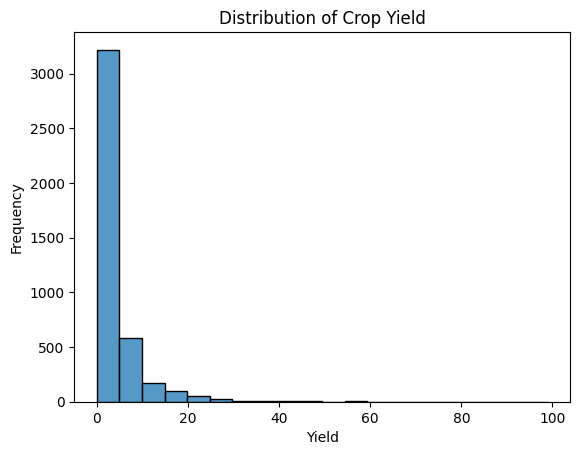

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['Yield'], bins=20)
plt.title("Distribution of Crop Yield")
plt.xlabel("Yield")
plt.ylabel("Frequency")
plt.show()

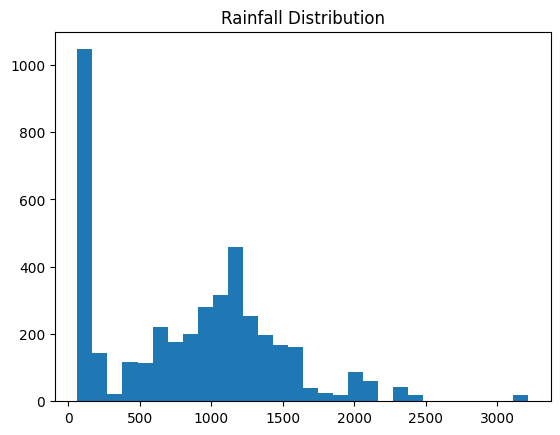

In [4]:
plt.hist(df["Rainfall"], bins=30)
plt.title("Rainfall Distribution")
plt.show()

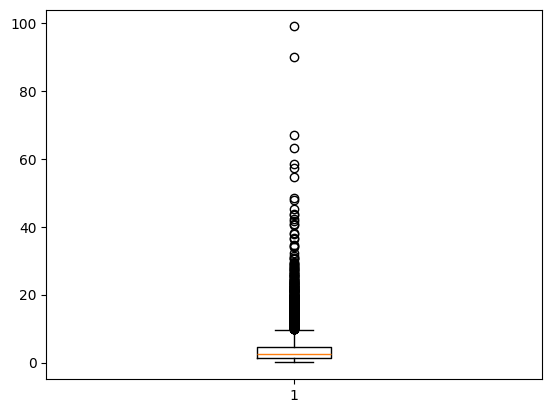

In [5]:
plt.boxplot(df["Yield"])
plt.show()

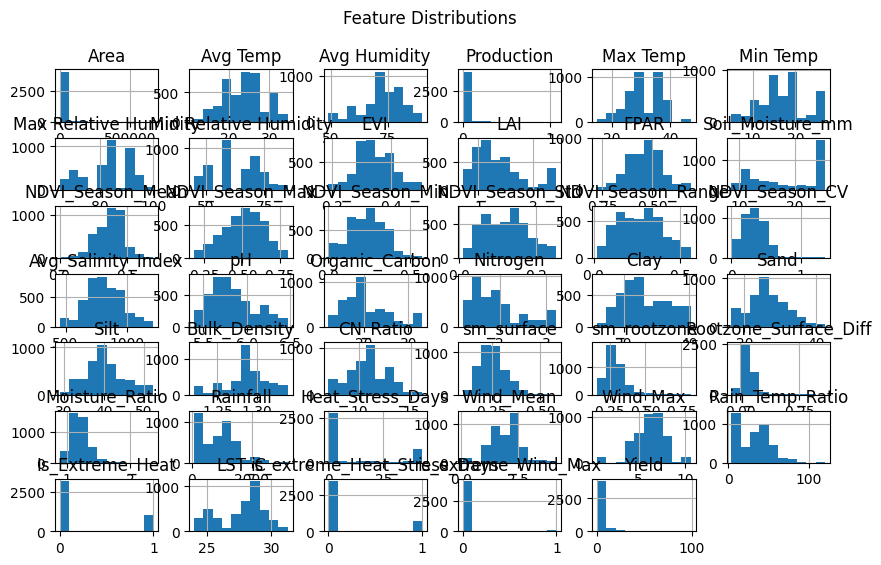

In [6]:
df.hist(figsize=(10,6))
plt.suptitle("Feature Distributions")
plt.show()

In [7]:
sns.scatterplot(x=df['NDVI'], y=df['yield'])
plt.title("NDVI vs Crop Yield")
plt.show()

KeyError: 'NDVI'